#  Mão na Roda — Baseline TF-IDF + Logistic Regression

**Universidade Presbiteriana Mackenzie**  
Faculdade de Computação e Informática  
Disciplina: Inteligência Artificial — 7ºN CC (Noite)  
Professor: Prof. Dr. Ivan Carlos Alcântara de Oliveira

---

**Projeto:** Mão na Roda — Sistema Inteligente para Diagnóstico Preliminar de Falhas Automotivas Baseado em PLN e Machine Learning

| Integrante | RA | E-mail |
|---|---|---|
| Diego Spagnuolo Sugai | 10417329 | diegossugai@gmail.com |
| Kauê Henrique Matias Alves | 10417894 | kauehmalves@gmail.com |
| Leonardo Moreira dos Santos | 10417555 | leonardomsantos12@gmail.com |
| Victor Maki Tarcha | 10419861 | victormakitarcha@gmail.com |

---

**Arquivo:** `baseline_e_resultados.ipynb`  
**Síntese:** Implementação do modelo baseline (TF-IDF + Logistic Regression) para classificação de falhas automotivas a partir de relatos em PT-BR. Inclui: pré-processamento de texto, vetorização TF-IDF com bigramas, validação cruzada estratificada (5-fold), matriz de confusão, relatório de classificação por classe, análise de feature importance, teste de robustez linguística e comparação de hiperparâmetros C. Prepara estrutura para comparação futura com BERTimbau.

**Histórico de alterações:**
- `2026-03-22` | Kauê Alves — Criação: pré-processamento e TF-IDF baseline  
- `2026-03-22` | Diego Sugai — Adição da validação cruzada e métricas  
- `2026-03-23` | Leonardo Santos — Adição da análise de robustez linguística  
- `2026-03-23` | Victor Tarcha — Feature importance, comparação C e exportação  

---
##  Seção 0 — Instalação de dependências e upload do dataset

In [10]:
# scikit-learn já vem pré-instalado no Colab
# Caso precise forçar versões específicas, descomente:
# !pip install scikit-learn pandas numpy matplotlib --quiet

In [11]:
# ─── Upload do dataset para o Colab ─────────────────────────────────────────
# Execute esta célula para fazer o upload do arquivo 'dataset_mao_na_roda.xlsx'
# (ou .csv) diretamente para o ambiente do Colab.

from google.colab import files

print(' Selecione o arquivo dataset_mao_na_roda.xlsx (ou .csv):')
uploaded = files.upload()

print('\n Arquivos carregados:', list(uploaded.keys()))

 Selecione o arquivo dataset_mao_na_roda.xlsx (ou .csv):


Saving dataset_mao_na_roda.xlsx to dataset_mao_na_roda (1).xlsx

 Arquivos carregados: ['dataset_mao_na_roda (1).xlsx']


---
##  Seção 1 — Importações e Configurações

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re
import os
import warnings
import json

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, f1_score)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
%matplotlib inline

OUTPUT_DIR  = 'figuras'
RESULTS_DIR = 'resultados'
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

PALETTE = [
    '#F4D03F','#E74C3C','#C0392B','#2ECC71',
    '#3498DB','#9B59B6','#1ABC9C','#E67E22',
    '#F39C12','#8E44AD',
]
RANDOM_STATE = 42

def salvar(nome):
    caminho = os.path.join(OUTPUT_DIR, nome)
    plt.savefig(caminho, dpi=150, bbox_inches='tight')
    print(f'   Figura salva: {caminho}')
    plt.show()  # Exibe inline no Colab
    plt.close()

def estilo_eixo(ax):
    ax.spines[['top', 'right']].set_visible(False)

print(' Importações e configurações concluídas!')

 Importações e configurações concluídas!


---
##  Seção 2 — Carregamento do Dataset

In [14]:
import glob

xlsx_files = glob.glob('*.xlsx') + glob.glob('dataset*.xlsx')
csv_files  = glob.glob('*.csv')  + glob.glob('dataset*.csv')

if xlsx_files:
    DATASET_PATH = xlsx_files[0]
    df = pd.read_excel(DATASET_PATH)
    print(f' Dataset carregado (Excel): {DATASET_PATH}')
elif csv_files:
    DATASET_PATH = csv_files[0]
    df = pd.read_csv(DATASET_PATH, encoding='utf-8-sig')
    print(f' Dataset carregado (CSV): {DATASET_PATH}')
else:
    raise FileNotFoundError(' Dataset não encontrado. Execute a célula de upload acima.')

# ── Diagnóstico: exibe colunas originais antes de qualquer renomeação ───────
print(f'\n Colunas originais do arquivo: {list(df.columns)}')

# ── Padronização dos nomes de colunas ───────────────────────────────────────
# O dataset usa nomes longos/descritivos; aqui mapeamos para os nomes
# internos usados pelo código (snake_case curto).
COLMAP = {
    'ID':                      'id',
    'Relato (Sintoma PT-BR)':  'relato',
    'Classe (Label)':          'falha_label',
    'Falha Diagnosticada':     'falha_descricao',
    'Custo Mín (R$)':          'custo_min_brl',
    'Custo Máx (R$)':          'custo_max_brl',
    'Custo Médio (R$)':        'custo_medio_brl',
    'Urgência':                'nivel_urgencia',
    'Tipo Linguístico':        'variacao_linguistica',
}
df.rename(columns=COLMAP, inplace=True)
print(f' Colunas após padronização: {list(df.columns)}')

CLASS_NAMES = df.groupby('falha_label')['falha_descricao'].first().to_dict()
CLASS_SHORT  = {k: v.replace('Sistema de ', '').replace('/', '/\n')
                for k, v in CLASS_NAMES.items()}

print(f'\n   Dataset carregado: {len(df)} relatos | {df["falha_label"].nunique()} classes')
display(df.head())

 Dataset carregado (Excel): dataset_mao_na_roda.xlsx

 Colunas originais do arquivo: ['ID', 'Relato (Sintoma PT-BR)', 'Classe (Label)', 'Falha Diagnosticada', 'Custo Mín (R$)', 'Custo Máx (R$)', 'Custo Médio (R$)', 'Urgência', 'Tipo Linguístico']
 Colunas após padronização: ['id', 'relato', 'falha_label', 'falha_descricao', 'custo_min_brl', 'custo_max_brl', 'custo_medio_brl', 'nivel_urgencia', 'variacao_linguistica']

   Dataset carregado: 170 relatos | 10 classes


,id,relato,falha_label,falha_descricao,custo_min_brl,custo_max_brl,custo_medio_brl,nivel_urgencia,variacao_linguistica
0,1,"O carro não liga de jeito nenhum, só dá um cli...",0,Bateria/Sistema Elétrico,150,600,375,alto,formal
1,2,"meu carro num liga nao, da so um tique quando ...",0,Bateria/Sistema Elétrico,150,600,375,alto,informal_erro_ortografico
2,3,"bateria morreu de novo, já é a terceira vez es...",0,Bateria/Sistema Elétrico,150,600,375,alto,informal
3,4,as luzes do painel piscam e o carro morre no s...,0,Bateria/Sistema Elétrico,150,800,475,alto,formal
4,5,"o alternador tá zuado, bateria não carrega",0,Bateria/Sistema Elétrico,300,900,600,alto,giria


---
##  Seção 3 — Pré-processamento de Texto

In [15]:
# ── Stopwords ───────────────────────────────────────────────────────────────
STOPWORDS_PT = {
    'o','a','os','as','e','de','do','da','dos','das','em','no','na','nos','nas',
    'um','uma','que','se','por','com','para','ao','aos','à','às','ou','mas','mais',
    'não','nao','num','numa','é','tá','tô','meu','minha','meus','minhas','quando',
    'depois','antes','muito','bem','todo','toda','tudo','já','só','lá','cá','pra',
    'pro','pras','pros','isso','esse','essa','esses','essas','este','esta','estes',
    'estas','foi','fui','tem','ter','ser','ir','eu','ele','ela','eles','elas','me',
    'te','nos','vos','lhe','lhes','também','mesmo','sempre','cada','entre','até',
    'sobre','então','porque','disso','desse','dessa','aqui','ali','aí','onde',
    'como','quanto','ficou','ficando','está','estou','estão','tinha','tenho',
    'faiz','tou','bom','ruim','carro','caro',
}

# ── Mapa de normalização de gírias/erros ortográficos ──────────────────────
NORMALIZACAO = {
    r'\btá\b':      'está',
    r'\btô\b':      'estou',
    r'\bnao\b':     'não',
    r'\bpra\b':     'para',
    r'\bpro\b':     'para o',
    r'\bmano\b':    '',
    r'\bnum\b':     'não',
    r'\btrem\b':    '',
    r'\bbaita\b':   'grande',
    r'\bfudido\b':  'danificado',
    r'\bpifou\b':   'quebrou',
    r'\bpipoca\b':  'falha',
    r'\bzuado\b':   'danificado',
    r'\bestourou\b':'quebrou',
    r'\bbosta\b':   '',
    r'\bbicho\b':   '',
}

print(f' Stopwords definidas : {len(STOPWORDS_PT)}')
print(f' Normalizações gírias: {len(NORMALIZACAO)}')

 Stopwords definidas : 112
 Normalizações gírias: 16


In [16]:
def preprocessar(texto):
    """
    Pipeline de pré-processamento:
    1. Lowercase
    2. Normalização de gírias/erros ortográficos
    3. Remoção de pontuação e números
    4. Remoção de stopwords
    5. Retorna texto limpo
    """
    t = str(texto).lower().strip()
    for pattern, replacement in NORMALIZACAO.items():
        t = re.sub(pattern, replacement, t)
    t = re.sub(r'[^a-záéíóúãõâêôàüç\s]', ' ', t)
    tokens = t.split()
    tokens = [tok for tok in tokens if tok not in STOPWORDS_PT and len(tok) > 2]
    return ' '.join(tokens)

df['relato_processado'] = df['relato'].apply(preprocessar)

print(' Pré-processamento aplicado!')
print('\n Exemplos antes/depois:')
for i in [0, 1, 16, 64]:
    if i < len(df):
        print(f'\n  [{i}] Original  : {df["relato"].iloc[i]}')
        print(f'       Processado: {df["relato_processado"].iloc[i]}')

X = df['relato_processado'].values
y = df['falha_label'].values

 Pré-processamento aplicado!

 Exemplos antes/depois:

  [0] Original  : O carro não liga de jeito nenhum, só dá um clique quando giro a chave
       Processado: liga jeito nenhum clique giro chave

  [1] Original  : meu carro num liga nao, da so um tique quando giro a chave
       Processado: liga tique giro chave

  [16] Original  : o freio tá esponjoso, afunda demais antes de segurar
       Processado: freio esponjoso afunda demais segurar

  [64] Original  : fluido de câmbio tá roxo e com cheiro de queimado
       Processado: fluido câmbio roxo cheiro queimado


---
##  Seção 4 — Pipeline Baseline: TF-IDF + Logistic Regression

In [17]:
print(' Construindo o pipeline baseline...')
print('   Vetorizador : TF-IDF (max_features=600, ngram_range=(1,2), sublinear_tf=True)')
print('   Classificador: Logistic Regression (C=1.0, solver=lbfgs, max_iter=1000)')

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=600,
        ngram_range=(1, 2),
        strip_accents='unicode',
        sublinear_tf=True,      # tf = 1 + log(tf) — suaviza termos frequentes
        min_df=1,
    )),
    ('clf', LogisticRegression(
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

print('\n Pipeline criado:')
print(pipeline)

 Construindo o pipeline baseline...
   Vetorizador : TF-IDF (max_features=600, ngram_range=(1,2), sublinear_tf=True)
   Classificador: Logistic Regression (C=1.0, solver=lbfgs, max_iter=1000)

 Pipeline criado:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=600, ngram_range=(1, 2),
                                 strip_accents='unicode', sublinear_tf=True)),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])


---
##  Seção 5 — Validação Cruzada Estratificada (5-Fold)

In [18]:
print(' Executando Validação Cruzada Estratificada (5-Fold)...')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_macro   = cross_val_score(pipeline, X, y, cv=cv, scoring='f1_macro')
f1_weight  = cross_val_score(pipeline, X, y, cv=cv, scoring='f1_weighted')

print(f"\n Resultados Baseline (TF-IDF + Logistic Regression):")
print(f"   {'Métrica':<25} {'Média':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}")
print(f"   {'-'*60}")
print(f"   {'Acurácia':<25} {acc_scores.mean():>8.4f}  {acc_scores.std():>8.4f}  {acc_scores.min():>8.4f}  {acc_scores.max():>8.4f}")
print(f"   {'F1-Macro':<25} {f1_macro.mean():>8.4f}  {f1_macro.std():>8.4f}  {f1_macro.min():>8.4f}  {f1_macro.max():>8.4f}")
print(f"   {'F1-Weighted':<25} {f1_weight.mean():>8.4f}  {f1_weight.std():>8.4f}  {f1_weight.min():>8.4f}  {f1_weight.max():>8.4f}")

 Executando Validação Cruzada Estratificada (5-Fold)...

 Resultados Baseline (TF-IDF + Logistic Regression):
   Métrica                      Média       Std       Min       Max
   ------------------------------------------------------------
   Acurácia                    0.6235    0.0974    0.5000    0.7647
   F1-Macro                    0.6070    0.1048    0.4802    0.7552
   F1-Weighted                 0.6102    0.1018    0.4915    0.7697


### Figura 9 — Validação Cruzada: Acurácia e F1 por Fold

   Figura salva: figuras/fig9_validacao_cruzada.png


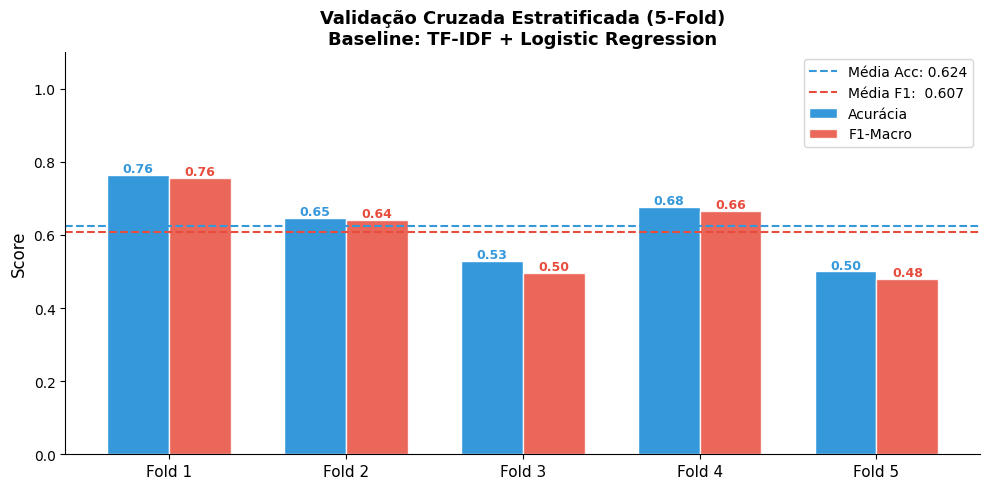

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(5)
width = 0.35
bars1 = ax.bar(x_pos - width / 2, acc_scores, width, label='Acurácia',
               color='#3498DB', edgecolor='white')
bars2 = ax.bar(x_pos + width / 2, f1_macro,   width, label='F1-Macro',
               color='#E74C3C', edgecolor='white', alpha=0.85)
ax.axhline(acc_scores.mean(), color='#3498DB', linestyle='--', linewidth=1.5,
           label=f'Média Acc: {acc_scores.mean():.3f}')
ax.axhline(f1_macro.mean(),   color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Média F1:  {f1_macro.mean():.3f}')
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{bar.get_height():.2f}', ha='center', fontsize=9,
            color='#3498DB', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{bar.get_height():.2f}', ha='center', fontsize=9,
            color='#E74C3C', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Fold {i + 1}' for i in range(5)], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Validação Cruzada Estratificada (5-Fold)\nBaseline: TF-IDF + Logistic Regression',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
estilo_eixo(ax)
plt.tight_layout()
salvar('fig9_validacao_cruzada.png')

---
##  Seção 6 — Treino Completo + Métricas por Classe

In [20]:
print(' Treinando no dataset completo...')
pipeline.fit(X, y)
y_pred = pipeline.predict(X)

report = classification_report(
    y, y_pred,
    target_names=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())],
    output_dict=True,
)
report_str = classification_report(
    y, y_pred,
    target_names=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())],
)

print('\n Classification Report (treino completo):')
print(report_str)

# Salvar relatório em JSON
with open(os.path.join(RESULTS_DIR, 'baseline_classification_report.json'), 'w',
          encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)
print(f' Relatório salvo em: {RESULTS_DIR}/baseline_classification_report.json')

 Treinando no dataset completo...

 Classification Report (treino completo):
                                precision    recall  f1-score   support

      Bateria/Sistema Elétrico       1.00      1.00      1.00        17
             Sistema de Freios       1.00      1.00      1.00        19
     Superaquecimento do Motor       1.00      0.94      0.97        16
       Suspensão/Amortecedores       1.00      0.94      0.97        17
 Sistema de Transmissão/Câmbio       1.00      1.00      1.00        17
             Vazamento de Óleo       0.94      1.00      0.97        17
      Sistema de Arrefecimento       0.94      1.00      0.97        16
                     Pneu/Roda       1.00      1.00      1.00        17
Sistema de Injeção/Combustível       0.95      1.00      0.97        18
        Sistema de Escapamento       1.00      0.94      0.97        16

                      accuracy                           0.98       170
                     macro avg       0.98      0.98      

### Figura 10 — Matriz de Confusão

   Figura salva: figuras/fig10_matriz_confusao.png


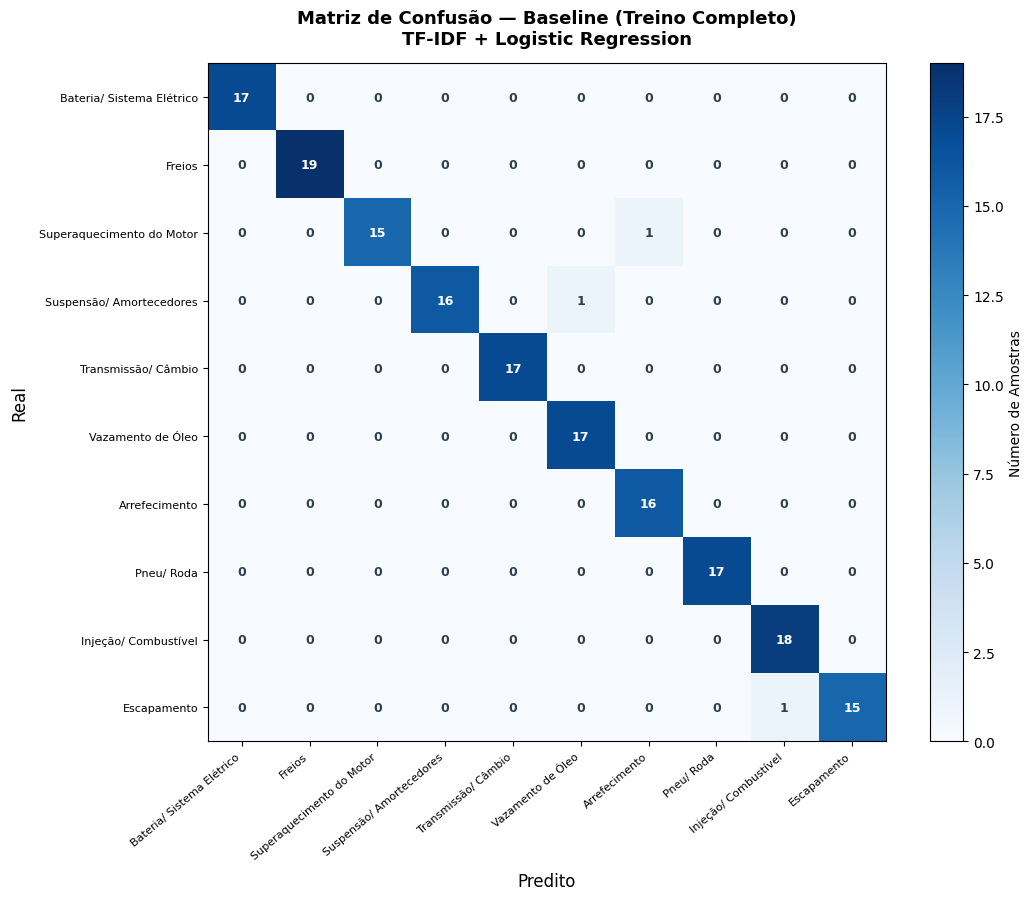

In [21]:
cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm, cmap='Blues')
labels_cm = [CLASS_SHORT[i].replace('\n', ' ') for i in sorted(CLASS_SHORT.keys())]
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(labels_cm, rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(labels_cm, fontsize=8)
for i in range(10):
    for j in range(10):
        val = cm[i, j]
        color = 'white' if val > cm.max() * 0.55 else '#2c3e50'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=9, fontweight='bold', color=color)
plt.colorbar(im, ax=ax, label='Número de Amostras')
ax.set_xlabel('Predito', fontsize=12, labelpad=8)
ax.set_ylabel('Real', fontsize=12, labelpad=8)
ax.set_title('Matriz de Confusão — Baseline (Treino Completo)\nTF-IDF + Logistic Regression',
             fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
salvar('fig10_matriz_confusao.png')

### Figura 11 — F1-Score por Classe

   Figura salva: figuras/fig11_f1_por_classe.png


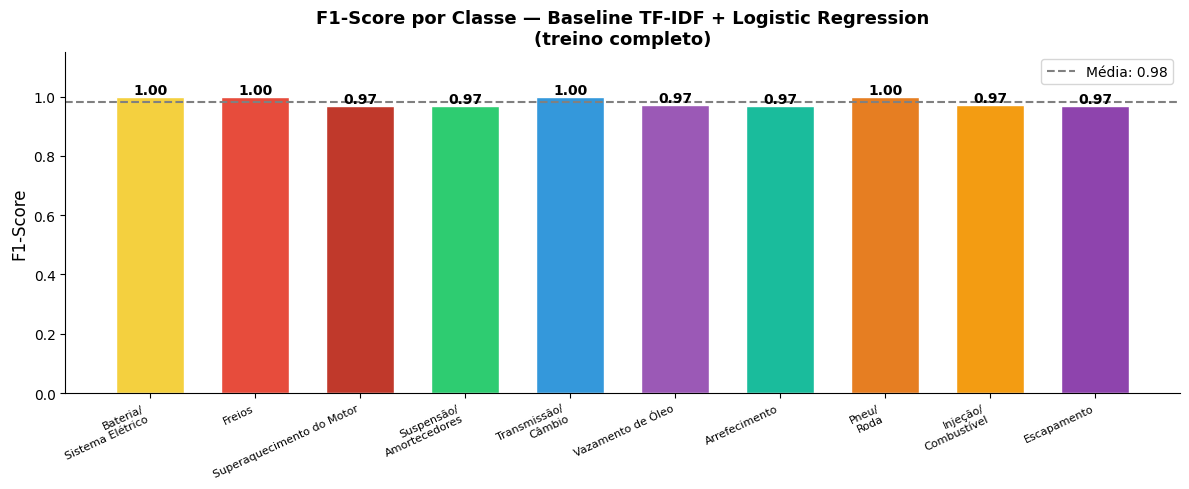

In [22]:
f1_per_class = f1_score(y, y_pred, average=None)
classes_names_short = [CLASS_NAMES[i].replace('Sistema de ', '').replace('/', '/\n')
                        for i in sorted(CLASS_NAMES.keys())]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(10), f1_per_class, color=PALETTE, edgecolor='white', width=0.65)
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01, f'{val:.2f}',
            ha='center', fontsize=10, fontweight='bold')
ax.axhline(f1_per_class.mean(), color='gray', linestyle='--', linewidth=1.5,
           label=f'Média: {f1_per_class.mean():.2f}')
ax.set_xticks(range(10))
ax.set_xticklabels(classes_names_short, fontsize=8, rotation=25, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('F1-Score por Classe — Baseline TF-IDF + Logistic Regression\n(treino completo)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
estilo_eixo(ax)
plt.tight_layout()
salvar('fig11_f1_por_classe.png')

### Figura 12 — Feature Importance: Top 8 Coeficientes por Classe

   Figura salva: figuras/fig12_feature_importance_por_classe.png


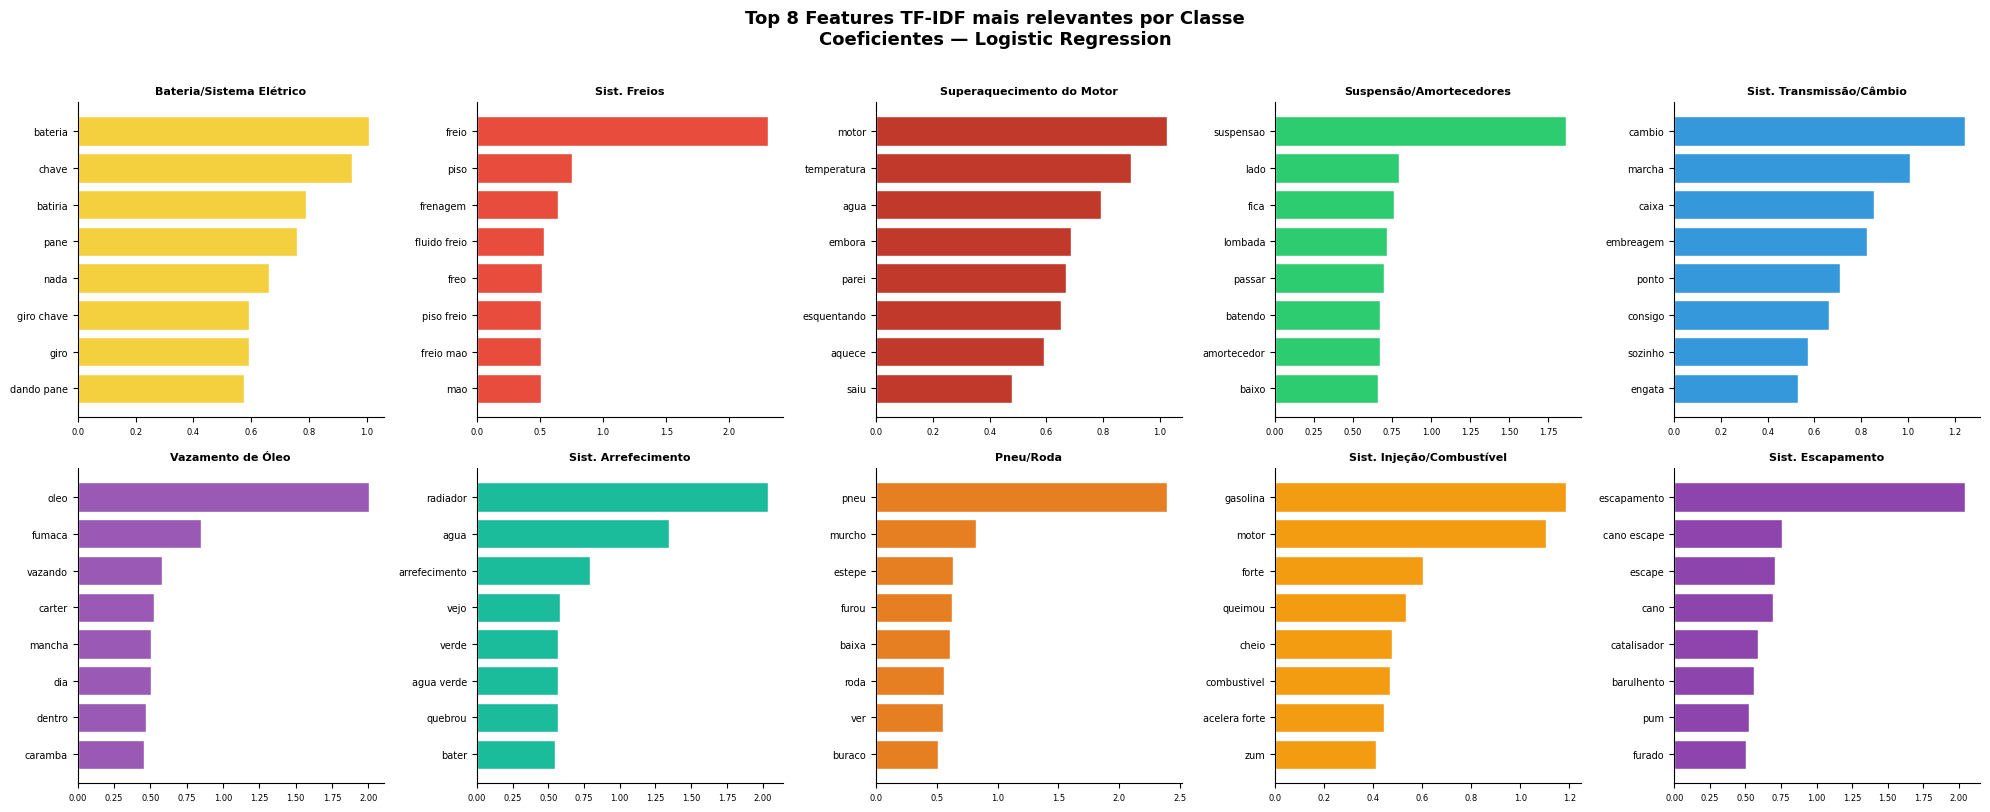

In [23]:
tfidf    = pipeline.named_steps['tfidf']
clf_step = pipeline.named_steps['clf']
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for class_idx in range(10):
    coefs    = clf_step.coef_[class_idx]
    top_idx  = np.argsort(coefs)[-8:]
    top_feat = feature_names[top_idx]
    top_coef = coefs[top_idx]
    axes[class_idx].barh(top_feat, top_coef, color=PALETTE[class_idx], edgecolor='white')
    axes[class_idx].set_title(
        CLASS_NAMES[class_idx].replace('Sistema de ', 'Sist. '),
        fontsize=8, fontweight='bold')
    axes[class_idx].tick_params(axis='y', labelsize=7)
    axes[class_idx].tick_params(axis='x', labelsize=6)
    axes[class_idx].spines[['top', 'right']].set_visible(False)
plt.suptitle('Top 8 Features TF-IDF mais relevantes por Classe\nCoeficientes — Logistic Regression',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
salvar('fig12_feature_importance_por_classe.png')

---
## 🗣️ Seção 7 — Análise de Robustez Linguística

In [24]:
print(' Robustez Linguística — Acurácia por Variação:')

rob_results = {}
for var_type in df['variacao_linguistica'].unique():
    mask   = df['variacao_linguistica'] == var_type
    X_sub  = df[mask]['relato_processado'].values
    y_sub  = df[mask]['falha_label'].values
    if len(y_sub) > 1:
        y_sub_pred = pipeline.predict(X_sub)
        acc = accuracy_score(y_sub, y_sub_pred)
        f1  = f1_score(y_sub, y_sub_pred, average='macro', zero_division=0)
        rob_results[var_type] = {'acc': acc, 'f1': f1, 'n': len(y_sub)}
        print(f'  {var_type:<35} | n={len(y_sub):>3} | Acc={acc:.3f} | F1={f1:.3f}')

 Robustez Linguística — Acurácia por Variação:
  formal                              | n= 83 | Acc=0.976 | F1=0.977
  informal_erro_ortografico           | n= 17 | Acc=0.941 | F1=0.926
  informal                            | n= 50 | Acc=1.000 | F1=1.000
  giria                               | n= 19 | Acc=1.000 | F1=1.000


### Figura 13 — Robustez Linguística por Tipo de Variação

   Figura salva: figuras/fig13_robustez_linguistica.png


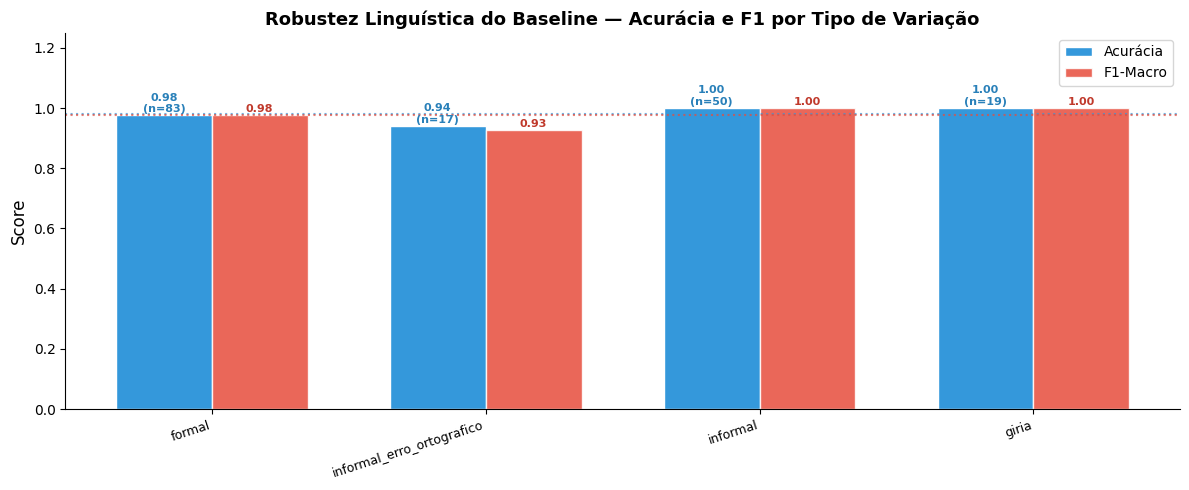

In [25]:
var_types = list(rob_results.keys())
accs_rob  = [rob_results[v]['acc'] for v in var_types]
f1s_rob   = [rob_results[v]['f1']  for v in var_types]
ns_rob    = [rob_results[v]['n']   for v in var_types]

fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(var_types))
width = 0.35
bars1 = ax.bar(x_pos - width / 2, accs_rob, width, label='Acurácia',
               color='#3498DB', edgecolor='white')
bars2 = ax.bar(x_pos + width / 2, f1s_rob,  width, label='F1-Macro',
               color='#E74C3C', edgecolor='white', alpha=0.85)
for bar, val, n in zip(bars1, accs_rob, ns_rob):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.2f}\n(n={n})', ha='center', fontsize=8, fontweight='bold', color='#2980B9')
for bar, val in zip(bars2, f1s_rob):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=8, fontweight='bold', color='#C0392B')
ax.axhline(np.mean(accs_rob), color='#3498DB', linestyle=':', alpha=0.7)
ax.axhline(np.mean(f1s_rob),  color='#E74C3C', linestyle=':', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(var_types, rotation=18, ha='right', fontsize=9)
ax.set_ylim(0, 1.25)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Robustez Linguística do Baseline — Acurácia e F1 por Tipo de Variação',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
estilo_eixo(ax)
plt.tight_layout()
salvar('fig13_robustez_linguistica.png')

---
##  Seção 8 — Tuning do Hiperparâmetro C (Regularização)

In [27]:
print(' Testando diferentes valores de C...')

C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
cv_small = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
acc_C, f1_C = [], []

for C in C_values:
    pipe_c = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=600, ngram_range=(1, 2),
            strip_accents='unicode', sublinear_tf=True, min_df=1)),
        ('clf', LogisticRegression(
            C=C, solver='lbfgs',
            max_iter=1000, random_state=RANDOM_STATE)),
    ])
    acc_C.append(cross_val_score(pipe_c, X, y, cv=cv_small, scoring='accuracy').mean())
    f1_C.append(cross_val_score(pipe_c, X, y, cv=cv_small, scoring='f1_macro').mean())
    print(f'  C={C:>6.2f} | Acc={acc_C[-1]:.4f} | F1={f1_C[-1]:.4f}')

best_idx = int(np.argmax(f1_C))
print(f'\n Melhor C (F1-Macro): C={C_values[best_idx]} → F1={f1_C[best_idx]:.4f}')

 Testando diferentes valores de C...
  C=  0.01 | Acc=0.1412 | F1=0.0377
  C=  0.05 | Acc=0.1824 | F1=0.0972
  C=  0.10 | Acc=0.3000 | F1=0.2605
  C=  0.50 | Acc=0.6000 | F1=0.5917
  C=  1.00 | Acc=0.6235 | F1=0.6070
  C=  2.00 | Acc=0.6294 | F1=0.6109
  C=  5.00 | Acc=0.6235 | F1=0.6049
  C= 10.00 | Acc=0.6235 | F1=0.6085

 Melhor C (F1-Macro): C=2.0 → F1=0.6109


### Figura 14 — Curva de Regularização: Acurácia e F1 em função de C

   Figura salva: figuras/fig14_tuning_C.png


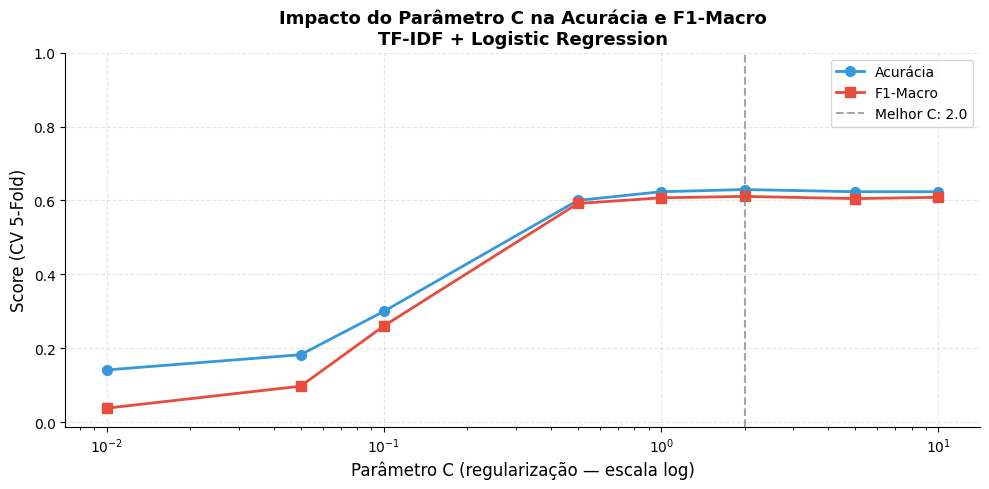

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(C_values, acc_C, 'o-', color='#3498DB', linewidth=2, markersize=7, label='Acurácia')
ax.plot(C_values, f1_C,  's-', color='#E74C3C', linewidth=2, markersize=7, label='F1-Macro')
ax.axvline(C_values[best_idx], color='gray', linestyle='--', alpha=0.7,
           label=f'Melhor C: {C_values[best_idx]}')
ax.set_xscale('log')
ax.set_xlabel('Parâmetro C (regularização — escala log)', fontsize=12)
ax.set_ylabel('Score (CV 5-Fold)', fontsize=12)
ax.set_title('Impacto do Parâmetro C na Acurácia e F1-Macro\nTF-IDF + Logistic Regression',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(min(min(acc_C), min(f1_C)) - 0.05, 1.0)
ax.grid(True, alpha=0.3, linestyle='--')
estilo_eixo(ax)
plt.tight_layout()
salvar('fig14_tuning_C.png')

---
##  Seção 9 — Tabela Comparativa: Baseline vs Modelos Avançados (N2)

In [31]:
resultados = {
    'Modelo': [
        'TF-IDF + Logistic Regression',
        'TF-IDF + SVM (previsto N2)',
        'BERTimbau fine-tuning (previsto N2)',
    ],
    'Acurácia (CV)': [
        f'{acc_scores.mean():.4f} ± {acc_scores.std():.4f}',
        'A calcular',
        'A calcular',
    ],
    'F1-Macro (CV)': [
        f'{f1_macro.mean():.4f} ± {f1_macro.std():.4f}',
        'A calcular',
        'A calcular',
    ],
    'Status': ['✓ Implementado', ' N2', ' N2'],
}
df_comp = pd.DataFrame(resultados)
print(' Tabela Comparativa de Modelos:')
display(df_comp)

df_comp.to_csv(os.path.join(RESULTS_DIR, 'tabela_comparativa_modelos.csv'),
               index=False, encoding='utf-8-sig')
print(f'\n Tabela salva em: {RESULTS_DIR}/tabela_comparativa_modelos.csv')

 Tabela Comparativa de Modelos:


,Modelo,Acurácia (CV),F1-Macro (CV),Status
0,TF-IDF + Logistic Regression,0.6235 ± 0.0974,0.6070 ± 0.1048,✓ Implementado
1,TF-IDF + SVM (previsto N2),A calcular,A calcular,N2
2,BERTimbau fine-tuning (previsto N2),A calcular,A calcular,N2



 Tabela salva em: resultados/tabela_comparativa_modelos.csv


### Figura 15 — Comparativo Visual de Métricas (parcial N1 vs previsto N2)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
modelos_plot  = ['Baseline\nTF-IDF + LR', 'SVM\n(N2)', 'BERTimbau\n(N2)']
acc_plot      = [acc_scores.mean(), 0, 0]
f1_plot       = [f1_macro.mean(), 0, 0]
cores_modelo  = ['#3498DB', '#BDC3C7', '#BDC3C7']
x_pos = np.arange(len(modelos_plot))
width = 0.35
b1 = ax.bar(x_pos - width / 2, acc_plot, width, label='Acurácia',
            color=cores_modelo, edgecolor='white')
b2 = ax.bar(x_pos + width / 2, f1_plot,  width, label='F1-Macro',
            color=['#E74C3C','#BDC3C7','#BDC3C7'], edgecolor='white', alpha=0.85)
for bar, val in zip(b1, acc_plot):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
for bar, val in zip(b2, f1_plot):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
for i in [1, 2]:
    ax.text(x_pos[i], 0.05, 'A implementar\nno N2', ha='center',
            fontsize=9, color='#7F8C8D', style='italic')
ax.set_xticks(x_pos)
ax.set_xticklabels(modelos_plot, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparação de Modelos — Resultados Parciais (N1)\nBaseline implementado | Modelos avançados previstos para N2',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.80, color='green', linestyle=':', alpha=0.5, label='Meta: 80%')
estilo_eixo(ax)
plt.tight_layout()
salvar('fig15_comparativo_modelos.png')

---
##  Seção 10 — Sumário Final, Exportação e Download

In [32]:
resumo = {
    'dataset': {
        'total_relatos': int(len(df)),
        'num_classes':   int(df['falha_label'].nunique()),
        'relatos_por_classe_media': float(round(len(df) / df['falha_label'].nunique(), 1)),
    },
    'pre_processamento': {
        'stopwords_removidas': len(STOPWORDS_PT),
        'normalizacoes_girias': len(NORMALIZACAO),
    },
    'baseline_cv': {
        'acuracia_media': float(round(acc_scores.mean(), 4)),
        'acuracia_std':   float(round(acc_scores.std(),  4)),
        'f1_macro_media': float(round(f1_macro.mean(),   4)),
        'f1_macro_std':   float(round(f1_macro.std(),    4)),
        'f1_weighted_media': float(round(f1_weight.mean(), 4)),
    },
    'melhor_C': C_values[best_idx],
    'robustez_linguistica': {k: {'acc': round(v['acc'], 4), 'f1': round(v['f1'], 4), 'n': v['n']}
                              for k, v in rob_results.items()},
}

with open(os.path.join(RESULTS_DIR, 'resumo_resultados_parciais.json'), 'w',
          encoding='utf-8') as f:
    json.dump(resumo, f, ensure_ascii=False, indent=2)

print('=' * 65)
print('  RESULTADOS PARCIAIS — RESUMO FINAL')
print('=' * 65)
print(f'\n  Dataset:  {len(df)} relatos | {df["falha_label"].nunique()} classes')
print(f'\n  Baseline TF-IDF + Logistic Regression (5-Fold CV):')
print(f'    Acurácia   : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}')
print(f'    F1-Macro   : {f1_macro.mean():.4f} ± {f1_macro.std():.4f}')
print(f'    F1-Weighted: {f1_weight.mean():.4f} ± {f1_weight.std():.4f}')
print(f'\n  Melhor C (tuning): {C_values[best_idx]}')
print(f'\n  Robustez (acurácia por variação linguística):')
for k, v in rob_results.items():
    print(f'    {k:<35}: {v["acc"]:.3f} (n={v["n"]})')
print(f'\n  Próximos passos (N2):')
print('    1. Fine-tuning BERTimbau (neuralmind/bert-base-portuguese-cased)')
print('    2. Comparação quantitativa Baseline vs BERT')
print('    3. Protótipo Streamlit com predição + confiança + orçamento')
print('=' * 65)

  RESULTADOS PARCIAIS — RESUMO FINAL

  Dataset:  170 relatos | 10 classes

  Baseline TF-IDF + Logistic Regression (5-Fold CV):
    Acurácia   : 0.6235 ± 0.0974
    F1-Macro   : 0.6070 ± 0.1048
    F1-Weighted: 0.6102 ± 0.1018

  Melhor C (tuning): 2.0

  Robustez (acurácia por variação linguística):
    formal                             : 0.976 (n=83)
    informal_erro_ortografico          : 0.941 (n=17)
    informal                           : 1.000 (n=50)
    giria                              : 1.000 (n=19)

  Próximos passos (N2):
    1. Fine-tuning BERTimbau (neuralmind/bert-base-portuguese-cased)
    2. Comparação quantitativa Baseline vs BERT
    3. Protótipo Streamlit com predição + confiança + orçamento


In [33]:
# ── Download de todas as figuras e resultados como ZIP ─────────────────────
import shutil
from google.colab import files

# ZIP das figuras
zip_figs = 'figuras_baseline'
shutil.make_archive(zip_figs, 'zip', OUTPUT_DIR)
files.download(f'{zip_figs}.zip')
print(' Download iniciado: figuras_baseline.zip')

# ZIP dos resultados JSON/CSV
zip_res = 'resultados_baseline'
shutil.make_archive(zip_res, 'zip', RESULTS_DIR)
files.download(f'{zip_res}.zip')
print(' Download iniciado: resultados_baseline.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Download iniciado: figuras_baseline.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Download iniciado: resultados_baseline.zip
